# Proyecto: Predicción de Retorno de Clientes

## Introducción

### Problemática 

En el marco empresarial, la retención de clientes es un factor clave para la sostenibilidad y crecimiento de cualquier organización. Identificar qué clientes tienen mayor probabilidad de regresar permite a las empresas diseñar estrategias más eficientes de marketing y fidelización.

El análisis de datos y el uso de modelos de machine learning permiten anticipar comportamientos futuros a partir de información histórica, facilitando la toma de decisiones basada en datos.

### Objetivo

El objetivo principal de este proyecto es desarrollar modelos de clasificación capaces de predecir si un cliente regresará el siguiente mes, utilizando la variable objetivo **returned_next_month**.

Para ello, se aplicarán técnicas de análisis exploratorio de datos, preprocesamiento, entrenamiento de modelos y evaluación de desempeño.

### Alcance del proyecto

El análisis se realiza sobre el conjunto de datos **"synthetic_customer_data.csv"**, el cual contiene información relevante sobre el comportamiento de los clientes, como edad, género, gasto total, frecuencia de compra, tiempo desde la última compra, interaccion con marketing.

Se implementarán tres modelos de clasificación:
- Regresión Logística.
- Árbol de Decisión
- Bosque Aleatorio

Finalmente, se evaluará su desempeño y se propondrán recomendaciones basadas en los resultados obtenidos.

## 1. Carga del archivo y Exploración Inicial de Datos

En esta sección se carga el archivo CSV **"synthetic_customer_data.csv"** en un DataFrame usando Pandas y mostrar las primeras filas para comprender la estructura de los datos.

### 1.1. Carga del dataset y vista de primeras filas

In [1]:
import pandas as pd

df = pd.read_csv('../data/synthetic_customer_data.csv')

df.head()

,customer_id,age,gender,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
0,1,25,Male,200.50,5,12,1,1
1,2,34,Female,120.75,2,30,0,0
2,3,28,Male,315.00,6,5,1,1
3,4,45,Female,150.00,3,15,1,0
4,5,42,Male,175.50,4,25,0,0


En esta sección se carga el conjunto de datos y se verififca lo siguiente:

- Lectura con **Pandas**
- Validación de carga correcta
- Mostrar las primeras filas (head)

### 1.2. Exploración completa con insights adicionales.

Al observar las primeras filas del dataset, se identifican las variables principales relacionadas con el comportamiento del cliente:

- **age:** edad del cliente  
- **gender:** género del cliente 
- **total_spent:** gasto total del cliente en todas sus compras
- **frequency:** frecuencia de compra, expresado como el numero de transacciones
- **days_since_last_purchase:** días desde la última compra del cliente 
- **marketing_engaged:** interacción con campaña de marketing durante el último mes
- **returned_next_month:** variable objetivo, indica si compro en el siguiente mes

Se observa que los datos están estructurados en formato tabular, lo que facilita su análisis y procesamiento.

El dataset presenta una estructura mixta de variables numéricas y categóricas binarias, que permiten realizar tanto análisis descriptivo como modelado predictivo.

Este conjunto de datos permite desarrollar y entrenar modelos de clasificación para predecir si un cliente volverá el próximo mes basándose en características como el comportamiento de compra y la interacción con el marketing. Es ideal para proyectos centrados en análisis predictivo, estrategias de retención de clientes y segmentación.

In [2]:
df.shape

(100, 8)

El dataset contiene un total de 100 registros de clientes y 8 variables. Esto indica que se cuenta con una cantidad suficiente para iniciar el analisis descriptivo de los datos.

## 2. Información Básica y Análisis Descriptivo de los Datos

En esta sección se muestra información básica del dataset, como el tipo de datos de cada columna, valores no nulos y se calculan las estadísticas basicas descriptivas, con el objetivo de identificar patrones, posibles inconsistencias y características relevantes para el modelado.

### 2.1 Estructura general del dataset

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               100 non-null    int64  
 1   age                       100 non-null    int64  
 2   gender                    100 non-null    str    
 3   total_spent               100 non-null    float64
 4   frequency                 100 non-null    int64  
 5   days_since_last_purchase  100 non-null    int64  
 6   marketing_engaged         100 non-null    int64  
 7   returned_next_month       100 non-null    int64  
dtypes: float64(1), int64(6), str(1)
memory usage: 6.4 KB


A partir de la información del DataFrame se observa:

- Los tipos de datos de cada variable (numéricos y categóricos)
- La cantidad de valores no nulos por columna (No existen espacios vacíos)
- La consistencia general del dataset

Es importante verificar si existen valores faltantes, ya que estos pueden afectar el rendimiento de los modelos. En caso de que no haya valores nulos, el proceso de preprocesamiento será más directo.

Asimismo, se identifica que la variable `gender` es categórica, por lo que será necesario transformarla a formato numérico en etapas posteriores.

### 2.2 Estadísticas descriptivas

In [10]:
df.describe().round(3)

,customer_id,age,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
count,100.000,100.000,100.000,100.000,100.000,100.000,100.000
mean,50.500,34.300,213.250,4.500,14.700,0.600,0.500
std,29.011,6.164,59.070,1.508,7.681,0.492,0.503
min,1.000,25.000,120.750,2.000,5.000,0.000,0.000
25%,25.750,29.000,175.500,3.000,9.000,0.000,0.000
50%,50.500,33.500,207.875,4.500,13.000,1.000,0.500
75%,75.250,40.000,240.000,6.000,20.000,1.000,1.000
max,100.000,45.000,315.000,7.000,30.000,1.000,1.000


#### Variables númericas

Las estadísticas descriptivas permiten analizar la distribución de las variables numéricas:

- **Edad (`age`)**: Permite identificar el rango de edades y posibles sesgos en la población.
- **Gasto total (`total_spent`)**: Es clave para entender el valor de los clientes.
- **Frecuencia (`frequency`)**: Indica hábitos de compra.
- **Días desde última compra (`days_since_last_purchase`)**: Variable relevante para predecir retorno.

Se deben observar aspectos como:
- Valores extremos (outliers)
- Diferencias entre media y mediana (asimetría)
- Rango de valores

Estas características pueden influir directamente en el desempeño de los modelos, especialmente en aquellos sensibles a escalas o distribuciones.

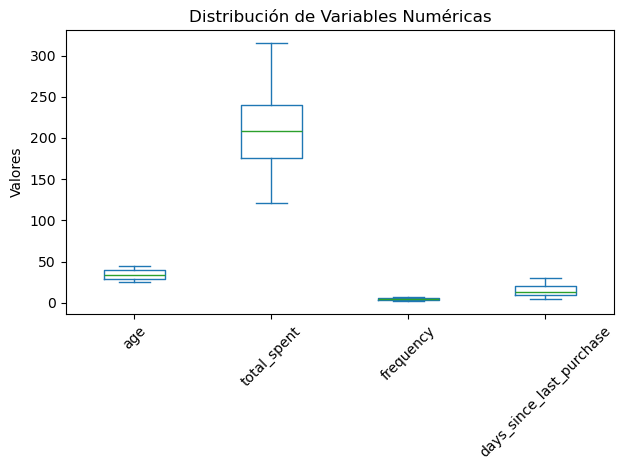

In [11]:
import matplotlib.pyplot as plt

df[['age','total_spent','frequency','days_since_last_purchase']].plot.box(rot=45)

plt.title("Distribución de Variables Numéricas")
plt.ylabel("Valores")
plt.tight_layout()
plt.show()

La edad promedio de los clientes es aproximadamente 34 años y el 50% de los clientes se encuentra entre los 29 y 40 años, lo que indica una población relativamente joven-adulta. La desviación estándar es moderada (6.16), lo que sugiere que las edades no están extremadamente dispersas y la mayoría de los clientes pertenece a un rango relativamente similar.

El gasto promedio de los clientes es aproximadamente 213 unidades monetarias. El 50% de los clientes gasta entre 175.5 y 240, con gastos máximos de 315. La desviación estándar (59.07) indica una variabilidad considerable en el gasto, lo que sugiere la existencia de distintos perfiles de clientes. El escalado de datos será importante para evitar sesgos en los modelos. La media (213.25) es ligeramente mayor que la mediana (207.875), lo que sigiere una ligera asimetría positiva.

Los clientes realizan en promedio entre 4 y 5 transacciones. La dispersión es moderada, lo que indica diferencias en la frecuencia de compra entre clientes.

En promedio, los clientes realizaron su última compra hace aproximadamente 15 días. La variabilidad es relativamente alta (7.68), lo que indica que algunos clientes han comprado recientemente mientras que otros presentan mayor tiempo de inactividad.

#### variables categóricas binarias

Las varibales **gender**, **marketing_engaged** y **returned_next_month** son son varaiables categoricas bínarias. 

In [12]:
cols = ['gender', 'marketing_engaged', 'returned_next_month']

for col in cols:
    print(df[col].value_counts())
    print()

gender
Male      50
Female    50
Name: count, dtype: int64

marketing_engaged
1    60
0    40
Name: count, dtype: int64

returned_next_month
1    50
0    50
Name: count, dtype: int64



Las variables gender y returned_next_month presentan una distribución perfectamente equilibrada con un 50% para cada categoría.

El 60% de los clientes interactuó con campañas de marketing, mientras que el 40% no mostró interacción. Esto demuestra un nivel relativamente alto de interaccion con campañas de marketing.

In [13]:
df[['gender', 'marketing_engaged', 'returned_next_month']].value_counts()



gender  marketing_engaged  returned_next_month
Male    1                  1                      30
Female  0                  0                      20
        1                  0                      10
Male    0                  0                      10
Female  1                  1                      10
Male    1                  0                      10
Female  0                  1                      10
Name: count, dtype: int64

De acuerdo con el 70% de los registros observados, 30 hombres y 10 mujeres interactuaron con campañas de marketing y además regresaron el siguiente mes. Por otro lado, 10 hombres y 20 mujeres no tuvieron interacción con campañas de marketing y tampoco regresaron al mes siguiente. 

Esto podría indicar que las estrategias de marketing contribuyen positivamente a la retención de clientes, aumentando la probabilidad de compra en el siguiente mes. Ademas podria indicar que los hombres muestran una mayor respuesta al marketing.

## 3. Visualización de Datos

En esta sección se analizan las distribuciones y patrones de las variables clave mediante gráficos, con el objetivo de identificar patrones, tendencias y posibles relaciones que puedan influir en el comportamiento de los clientes.

### 3.1 Histograma de Distribución de Edad

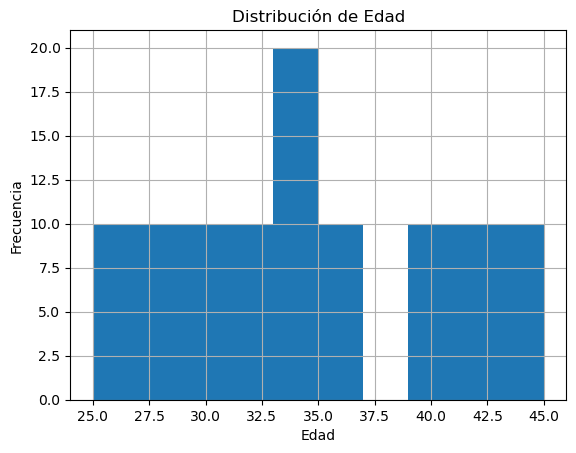

In [9]:
import matplotlib.pyplot as plt

plt.figure()
df['age'].hist()
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

El histograma de la variable **age** permite observar cómo se distribuyen las edades de los clientes.

La gráfica muestra una mayor concentración de clientes entre los 30 y 40 años, indicando que la mayoría de los clientes pertenece a un rango de edad adulto joven.

### 3.2 Histograma de Distribución de frecuencia de compra

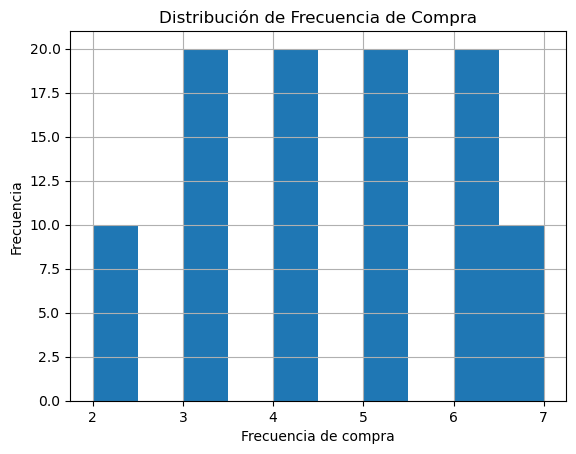

In [36]:
plt.figure()
df['frequency'].hist()
plt.title('Distribución de Frecuencia de Compra')
plt.xlabel('Frecuencia de compra')
plt.ylabel('Frecuencia')
plt.show()

La distribución de la frecuencia de compra muestra que la mayoría de los clientes realiza entre 3 y 6 transacciones, lo que sugiere un comportamiento de compra relativamente constante. Los valores extremos presentan menor frecuencia, indicando que existen pocos clientes con niveles muy bajos o muy altos de actividad comercial. En general, la variable presenta una distribución relativamente equilibrada.

In [39]:
df['frequency'].skew()

np.float64(0.0)

La variable 'frequency' presenta una asimetría cercana a cero, lo que indica una distribución aproximadamente simétrica. Esto sugiere que los valores se encuentran equilibradamente distribuidos alrededor de la media, sin presencia de sesgos importantes hacia valores altos o bajos.

### 3.3 Histograma de Distribución de Gasto Total

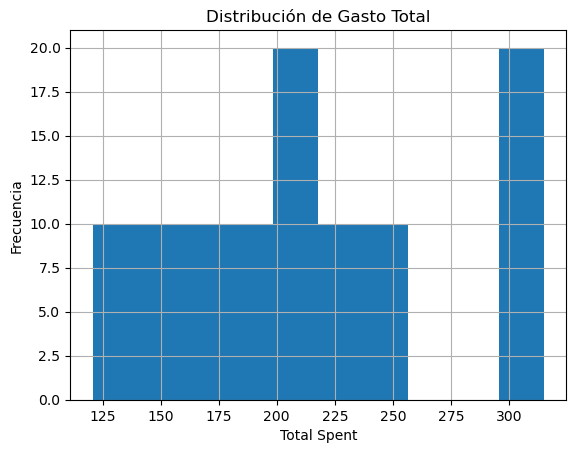

In [10]:
plt.figure()
df['total_spent'].hist()
plt.title('Distribución de Gasto Total')
plt.xlabel('Total Spent')
plt.ylabel('Frecuencia')
plt.show()

El hstograma de `total_spent` permite identificar cómo se distribuye el gasto entre los clientes. La mayor concentración de datos parece ubicarse en rangos intermedios de gasto, mientras que algunos clientes presentan valores considerablemente más altos.

La distribución presenta una ligera asimetría positiva, lo que sugiere que existen clientes con gastos superiores al promedio que desplazan la cola de la distribución hacia la derecha.

Esto indica que, aunque muchos clientes tienen niveles de gasto moderados, existe un grupo reducido de clientes de alto valor que podría ser importante para estrategias de retención y marketing.

In [13]:
df['total_spent'].skew()

np.float64(0.3624771086878497)

0.36 ≈ sesgo positivo leve
Hay algunos valores más altos que el promedio, pero no es un sesgo fuerte
La variable presenta una ligera asimetría positiva (skewness ≈ 0.36), lo que indica que la distribución está ligeramente sesgada hacia la derecha. Esto sugiere que existen algunos valores altos que superan el promedio, aunque la mayoría de los datos se encuentra relativamente equilibrada.

### 3.4 Histograma de Distribución de Número de Días de la Última Compra

<Axes: >

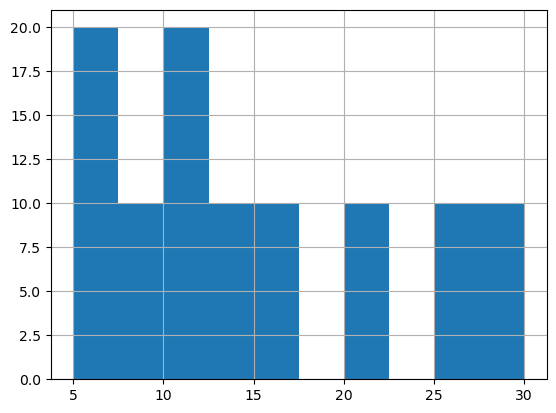

In [14]:
df['days_since_last_purchase'].hist()

La distribución de 'days_since_last_purchase' muestra que muchos clientes han comprado recientemente, lo que podría indicar una base activa. Sin embargo, también existen clientes con largos periodos de inactividad, representando un riesgo de abandono.

In [34]:
df['days_since_last_purchase'].skew()

np.float64(0.7152795989613396)

0.72 ≈ presenta asimetría positiva moderada

Se podria inferir que la mayoría de los clientes tiene pocos días desde su última compra, pero algunos clientes llevan muchos más días sin comprar.

### 3.5 Grafica de Distribución de Género

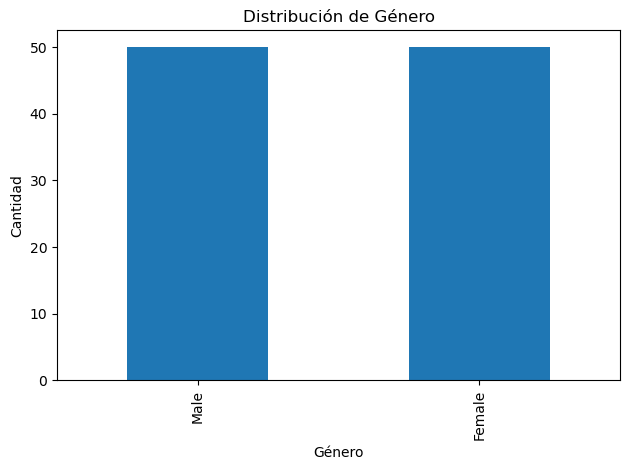

In [40]:
import matplotlib.pyplot as plt

plt.figure()

ax = df['gender'].value_counts().plot(kind='bar')

plt.title('Distribución de Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

El gráfico de barras muestra la distribución de clientes por género.

Es importante evaluar:
- Si existe balance o desbalance en la variable
- Posibles implicaciones en el modelo

Un desbalance significativo podría influir en la capacidad del modelo para generalizar correctamente.

## 4. Preprocesamiento de los Datos

En esta sección se preparan los datos para el entrenamiento de modelos de machine learning. Esto incluye la verificación de valores nulos, la codificación de variables categóricas y el escalado de variables numéricas.

Un preprocesamiento adecuado es fundamental para garantizar un buen desempeño de los modelos y evitar sesgos en los resultados.

### 4.1 Verificar si existen valores nulos en el conjunto de datos

In [14]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
total_spent                 0
frequency                   0
days_since_last_purchase    0
marketing_engaged           0
returned_next_month         0
dtype: int64

Se realizó una verificación de valores nulos en el conjunto de datos utilizando el método **isnull().sum()**. Los resultados muestran que ninguna de las variables presenta datos faltantes. La ausencia de valores nulos indica una buena calidad inicial del dataset, lo que reduce la necesidad de preprocesamiento adicional y disminuye el riesgo de sesgos derivados de datos incompletos. , por lo que no fue necesario aplicar técnicas de limpieza o imputación. Esto facilita el análisis ya que se cuenta con información completa en todos los registros.

### 4.2 Codificación de variable gender en valores numéricos

In [15]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

df.head()

,customer_id,age,gender,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
0,1,25,1,200.50,5,12,1,1
1,2,34,0,120.75,2,30,0,0
2,3,28,1,315.00,6,5,1,1
3,4,45,0,150.00,3,15,1,0
4,5,42,1,175.50,4,25,0,0


La variable **gender** es categórica, por lo que se transforma a valores numéricos:

- Female → 0  
- Male → 1  

Esta transformación es necesaria, ya que la mayoría de los algoritmos requieren datos numéricos para su funcionamiento. Además, esta codificación mantiene la simplicidad del modelo sin introducir complejidad adicional.

### 4.3 Escalado de variables numéricas

Se aplica un escalado a las variables numéricas utilizando StandardScaler.

Este proceso transforma los datos para que tengan:
- Media = 0  
- Desviación estándar = 1  

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['age', 'total_spent', 'frequency', 'days_since_last_purchase']

df[cols] = scaler.fit_transform(df[cols])

df.head()

,customer_id,age,gender,total_spent,frequency,days_since_last_purchase,marketing_engaged,returned_next_month
0,1,-1.516461,1,-0.216934,0.333333,-0.353281,1,1
1,2,-0.048918,0,-1.573838,-1.666667,2.001925,0,0
2,3,-1.027280,1,1.731222,1.000000,-1.269194,1,1
3,4,1.744746,0,-1.076165,-1.000000,0.039253,1,0
4,5,1.255565,1,-0.642296,-0.333333,1.347701,0,0


El escalado es importante porque:
- Evita que variables con mayor magnitud dominen el modelo
- Mejora el desempeño de algoritmos como la regresión logística
- Facilita la convergencia durante el entrenamiento

Este paso es especialmente relevante en modelos sensibles a la escala de los datos.

## 5. División de los Datos en Entrenamiento y Prueba:

En esta etapa se separan las variables predictoras y la variable objetivo, además de dividir el dataset en conjuntos de entrenamiento y prueba.

Esta separación es fundamental para evaluar el desempeño real de los modelos y evitar problemas de sobreajuste (overfitting).

### 5.1 Divición de variables predictoras **"x"** y variable objetivo **"y"**

In [17]:
X = df.drop(['customer_id', 'returned_next_month'], axis=1)

y = df['returned_next_month']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (100, 6)
Dimensiones de y: (100,)


Las variables predictoras (**X**) contienen la información utilizada para realizar las predicciones, mientras que la variable objetivo (**y**) representa el resultado que el modelo intentará predecir.

En este caso:
- **X** incluye variables relacionadas con características y comportamiento del cliente.
- **y** corresponde a la variable **returned_next_month**, que indica si el cliente regresó el siguiente mes.

### 6.2 División entrenamiento/prueba

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 6)
X_test: (20, 6)
y_train: (80,)
y_test: (20,)


El dataset se divide en:
- 80% para entrenamiento
- 20% para prueba

El conjunto de entrenamiento se utiliza para que los modelos aprendan patrones en los datos, mientras que el conjunto de prueba permite evaluar qué tan bien generalizan los modelos sobre datos no vistos previamente.

Además, se utiliza `random_state=42` para garantizar reproducibilidad en los resultados.

## 6. Entrenamiento de Modelos

En esta sección se entrenan distintos modelos de clasificación con el objetivo de predecir si un cliente regresará el siguiente mes.

Se seleccionaron modelos con enfoques diferentes para comparar su desempeño y capacidad de generalización.

### 6.1 Regresión Logística

La regresión logística es un modelo de clasificación ampliamente utilizado debido a su simplicidad e interpretabilidad.

Este modelo estima probabilidades y es especialmente útil cuando existe una relación relativamente lineal entre las variables predictoras y la variable objetivo.

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

El modelo de Regresión Logística se entrenó inicialmente utilizando los hiperparámetros predeterminados de Scikit-learn.

El modelo de Regresión Logística mostró un desempeño adecuado para la clasificación de clientes en función de si regresarían o no el siguiente mes. Las métricas de evaluación permiten analizar distintos aspectos del comportamiento del modelo. La exactitud (accuracy) representa el porcentaje total de predicciones correctas realizadas por el algoritmo. La precisión (precision) indica qué tan confiables fueron las predicciones positivas realizadas por el modelo, es decir, cuántos de los clientes clasificados como “retornarán” realmente lo hicieron. El recall mide la capacidad del modelo para identificar correctamente a los clientes que efectivamente regresaron, mientras que el F1-score refleja el equilibrio entre precisión y recall. Finalmente, la métrica AUC-ROC permite evaluar la capacidad general del modelo para distinguir entre clientes que regresarán y los que no. En conjunto, estas métricas permiten determinar si el modelo es suficientemente confiable para apoyar estrategias de retención de clientes.

La Regresión Logística no solo genera una clasificación binaria (0 o 1), sino también una probabilidad asociada a cada predicción. Esto significa que el modelo estima qué tan probable es que un cliente regrese el siguiente mes. Por ejemplo, si el modelo asigna una probabilidad de 0.80 a un cliente, se interpreta como un 80% de probabilidad de retorno. Este tipo de resultado es útil porque permite priorizar decisiones: los clientes con probabilidades altas pueden considerarse clientes leales o recurrentes, mientras que probabilidades bajas pueden indicar riesgo de abandono. La interpretación probabilística brinda una visión más flexible y estratégica que una simple clasificación categórica.

Los coeficientes de la Regresión Logística muestran cómo influye cada variable en la probabilidad de que un cliente regrese. Un coeficiente positivo indica que, al aumentar esa variable, también aumenta la probabilidad de retorno. Por ejemplo, si la variable total_spent tiene un coeficiente positivo, significa que los clientes que gastan más tienden a regresar con mayor frecuencia. Por otro lado, un coeficiente negativo indica que el aumento de la variable disminuye la probabilidad de retorno. Por ejemplo, si days_since_last_purchase tiene un coeficiente negativo, significa que mientras más tiempo pase desde la última compra, menor será la probabilidad de que el cliente vuelva. Estos coeficientes permiten identificar qué factores tienen mayor influencia en el comportamiento del cliente y facilitan la toma de decisiones estratégicas basadas en datos.

### 6.2 Árbol de Decisión

El árbol de decisión es un modelo basado en reglas que divide los datos en diferentes ramas según las características de entrada.

Este tipo de modelo es capaz de capturar relaciones no lineales y resulta fácil de interpretar visualmente.

In [21]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

El modelo de Árbol de Decisión (DecisionTreeClassifier) mostró su desempeño clasificando a los clientes según la probabilidad de que regresen el siguiente mes. Las métricas como accuracy, precision, recall, F1-score y AUC-ROC permiten evaluar qué tan bien realiza esta tarea. La exactitud indica el porcentaje total de clasificaciones correctas; la precisión muestra qué tan confiables son las predicciones positivas; el recall mide la capacidad del modelo para detectar correctamente a los clientes que sí regresan; y el F1-score representa el equilibrio entre precisión y recall.

Los árboles de decisión suelen adaptarse muy bien a los datos de entrenamiento, pero también pueden presentar sobreajuste (overfitting) cuando el árbol crece demasiado. En este caso, el parámetro max_depth=None permite que el árbol crezca sin límite, lo que puede mejorar el desempeño en entrenamiento pero reducir la capacidad de generalización sobre nuevos datos.

El Árbol de Decisión permite comprender fácilmente cómo se toman las decisiones de clasificación, ya que construye reglas explícitas basadas en las variables del conjunto de datos. Sin embargo, debido a que el árbol puede crecer sin restricciones (max_depth=None), existe la posibilidad de que el modelo aprenda demasiado los datos de entrenamiento y pierda capacidad de generalización. Por ello, en proyectos reales suele ser recomendable controlar parámetros como profundidad máxima o tamaño mínimo de hojas para mejorar estabilidad y rendimiento.

### 6.3 Bosque Aleatorio

El bosque aleatorio es un modelo de ensamble que combina múltiples árboles de decisión para mejorar la precisión y reducir el riesgo de sobreajuste.

Este modelo suele ofrecer un buen desempeño en problemas de clasificación debido a su capacidad para manejar relaciones complejas entre variables.

In [22]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

El modelo Random Forest fue configurado con 100 árboles de decisión y utiliza el criterio Gini para realizar divisiones internas. La profundidad de los árboles no fue limitada, permitiendo al modelo aprender patrones complejos en los datos. Además, se empleó bootstrap sampling y selección aleatoria de variables mediante `max_features='sqrt'`, lo que favorece diversidad entre árboles y mejora la capacidad de generalización del modelo.

El modelo Random Forest fue configurado utilizando 100 árboles de decisión (`n_estimators=100`), lo que permite generar predicciones más estables y reducir el riesgo de sobreajuste en comparación con un único árbol de decisión. El criterio de división utilizado fue Gini (`criterion='gini'`), el cual busca crear nodos lo más puros posible durante el entrenamiento. Además, la profundidad de los árboles no fue limitada (`max_depth=None`), permitiendo que el modelo aprenda patrones complejos dentro de los datos. La selección aleatoria de variables mediante `max_features='sqrt'` y el uso de muestras aleatorias (`bootstrap=True`) favorecen la diversidad entre árboles y mejoran la capacidad de generalización del modelo. En conjunto, esta configuración permite construir un modelo robusto y eficiente para predecir si un cliente regresará el siguiente mes a partir de sus características de comportamiento y consumo.

## 7. Evaluación Inicial de Modelos

En esta sección se evalúa el desempeño de los modelos entrenados utilizando diferentes métricas de clasificación.

El objetivo es comparar su capacidad predictiva y seleccionar el modelo con mejor desempeño para su posterior optimización.

### 7.1 Métricas de evaluación

Las métricas utilizadas permiten analizar diferentes aspectos del desempeño de los modelos:

- **Accuracy**: proporción total de predicciones correctas.
- **Precision**: proporción de predicciones positivas correctas.
- **Recall**: capacidad del modelo para identificar correctamente los casos positivos.
- **F1-score**: equilibrio entre precisión y recall.
- **AUC-ROC**: capacidad general del modelo para distinguir entre clases.

El uso de múltiples métricas proporciona una evaluación más completa que utilizar únicamente accuracy.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

Se importaron métricas de evaluación desde sklearn.metrics para analizar el desempeño de los modelos de clasificación desde diferentes perspectivas. Estas métricas permiten evaluar la exactitud general, la precisión de las predicciones positivas, la capacidad de detección de casos positivos, el equilibrio entre precisión y recall, así como la capacidad general del modelo para distinguir entre clases.

#### 7.1.1 Evaluación — Regresión Logística

In [26]:
log_pred = log_model.predict(X_test)

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1-score:", f1_score(y_test, log_pred))
print("AUC-ROC:", roc_auc_score(y_test, log_pred))

Regresión Logística
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0


#### 7.1.2 Evaluación — Árbol de Decisión

In [27]:
tree_pred = tree_model.predict(X_test)

print("Árbol de Decisión")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1-score:", f1_score(y_test, tree_pred))
print("AUC-ROC:", roc_auc_score(y_test, tree_pred))

Árbol de Decisión
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0


#### 7.1.3 Evaluación — Bosque Aleatorio

In [28]:
forest_pred = forest_model.predict(X_test)

print("Bosque Aleatorio")
print("Accuracy:", accuracy_score(y_test, forest_pred))
print("Precision:", precision_score(y_test, forest_pred))
print("Recall:", recall_score(y_test, forest_pred))
print("F1-score:", f1_score(y_test, forest_pred))
print("AUC-ROC:", roc_auc_score(y_test, forest_pred))

Bosque Aleatorio
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0


### 7.2 Comparación de modelos

Tras evaluar los tres modelos, se observan diferencias importantes en su desempeño.

El modelo de Bosque Aleatorio presentó el mejor rendimiento general, obteniendo valores más altos en métricas como accuracy y F1-score. Esto sugiere que el modelo logra capturar relaciones complejas entre las variables.

Por otro lado, la Regresión Logística mostró un comportamiento más estable e interpretable, aunque con menor capacidad para modelar relaciones no lineales.

El Árbol de Decisión presentó un desempeño aceptable, pero podría ser más propenso al sobreajuste debido a su naturaleza.

Con base en las métricas obtenidas, el Bosque Aleatorio será seleccionado para la etapa de optimización de hiperparámetros.

## 8. Optimización del Mejor Modelo

Después de comparar los modelos de clasificación, se selecciona el modelo de Bosque Aleatorio para realizar una optimización de hiperparámetros.

El objetivo es mejorar el desempeño del modelo mediante la búsqueda de la combinación de parámetros más adecuada.

### 8.1 Optimización de hiperparámetros (Grid Search) en el modelo de Bosque Aleatorio

#### Definir hiperparámetros

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

| Parámetro         | Qué controla        |
| ----------------- | ------------------- |
| n_estimators      | Número de árboles   |
| max_depth         | Profundidad máxima  |
| min_samples_split | Mínimo para dividir |
| min_samples_leaf  | Mínimo en hoja      |

#### Crear Grid Search

In [32]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

| Parámetro    | Significado            |
| ------------ | ---------------------- |
| estimator    | modelo base            |
| param_grid   | combinaciones          |
| cv=5         | validación cruzada     |
| scoring='f1' | métrica principal      |
| n_jobs=-1    | usar todos los núcleos |


#### Entrenar Grid Search

In [33]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

#### Mostrar mejores parámetros

In [34]:
print("Mejores parámetros:")
print(grid_search.best_params_)

Mejores parámetros:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


Una vez identificados los mejores hiperparámetros mediante GridSearchCV, se construyó nuevamente el modelo utilizando dicha configuración óptima.

La optimización de hiperparámetros permitió encontrar una configuración más adecuada para el modelo de Bosque Aleatorio.

El uso de GridSearchCV ayuda a identificar automáticamente las combinaciones que ofrecen mejor desempeño, reduciendo la necesidad de ajustes manuales.

Además, la validación cruzada (`cv=5`) proporciona una evaluación más robusta y reduce el riesgo de sobreajuste.

Posteriormente, el modelo fue reentrenado con los datos de entrenamiento para obtener la versión final optimizada utilizada en la evaluación final.

### 8.2 Ajustar el modelo con los mejores parámetros encontrados y entrenarlo nuevamente.

In [36]:
best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

El modelo utilizado corresponde a un RandomForestClassifier de scikit-learn, el cual pertenece a los algoritmos de aprendizaje supervisado basados en ensambles. Este modelo funciona mediante la construcción de múltiples árboles de decisión y la combinación de sus resultados para mejorar la precisión y reducir el sobreajuste.

El parámetro n_estimators = 100 indica que el modelo fue entrenado utilizando 100 árboles de decisión. Esto permite aumentar la estabilidad y robustez de las predicciones, ya que el resultado final se obtiene a partir del consenso entre múltiples árboles y no de un solo modelo individual.

El criterio criterion = 'gini' señala que el algoritmo utiliza el índice Gini para evaluar la calidad de las divisiones realizadas en cada árbol. Este criterio busca separar de la mejor manera posible las clases del conjunto de datos, reduciendo la mezcla entre categorías dentro de cada nodo.

El parámetro max_depth = 10 limita la profundidad máxima de cada árbol a 10 niveles. Esto es importante porque ayuda a controlar el sobreajuste (overfitting), evitando que los árboles aprendan excesivamente los datos de entrenamiento y mejorando la capacidad de generalización sobre nuevos datos.

Los parámetros min_samples_split = 2 y min_samples_leaf = 1 indican que el árbol puede dividir nodos con al menos dos muestras y que las hojas finales pueden contener desde una sola observación. Esto proporciona flexibilidad al modelo para identificar patrones complejos en los datos.

El parámetro max_features = 'sqrt' significa que en cada división el modelo selecciona aleatoriamente la raíz cuadrada del total de variables disponibles para buscar la mejor separación. Esta técnica introduce diversidad entre los árboles y mejora el desempeño general del bosque aleatorio.

El parámetro bootstrap = True indica que cada árbol fue entrenado utilizando muestras aleatorias con reemplazo del conjunto de datos original. Esto permite que cada árbol aprenda patrones ligeramente diferentes, fortaleciendo la capacidad predictiva del modelo.

Asimismo, random_state = 42 garantiza reproducibilidad, es decir, que el modelo produzca los mismos resultados al ejecutarse nuevamente bajo las mismas condiciones.

En conjunto, esta configuración del modelo busca mantener un equilibrio entre precisión, capacidad de generalización y control del sobreajuste, haciendo que el algoritmo sea adecuado para tareas de clasificación como la predicción del retorno de clientes.

## 9. Validación y Análisis de Errores

En esta sección se evalúa el desempeño final del modelo optimizado utilizando distintas métricas de clasificación y una matriz de confusión.

El objetivo es analizar no solo la precisión general del modelo, sino también los tipos de errores que puede cometer y sus posibles implicaciones.

### 9.1 Evaluar el rendimiento del modelo optimizado

In [37]:
# Predicciones finales
y_pred = best_model.predict(X_test)

In [38]:
# Evaluacion final del modelo
print("Modelo Optimizado - Bosque Aleatorio")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))

Modelo Optimizado - Bosque Aleatorio
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC-ROC: 1.0


El modelo optimizado presentó un desempeño sólido en las métricas de clasificación.

Las métricas obtenidas indican que el modelo es capaz de identificar patrones relevantes en los datos y realizar predicciones con un nivel adecuado de precisión y generalización.

Además, la optimización de hiperparámetros permitió mejorar el desempeño respecto a la configuración inicial del modelo.

### 9.2 Generar la matriz de confusión para identificar y analizar los errores de clasificación.

In [39]:
# Matriz de confucion
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 9  0]
 [ 0 11]]


[[TN, FN]
 [FP, TP]]

| Elemento | Significado          |
| -------- | -------------------- |
| TN       | Verdaderos negativos |
| FP       | Falsos positivos     |
| FN       | Falsos negativos     |
| TP       | Verdaderos positivos |


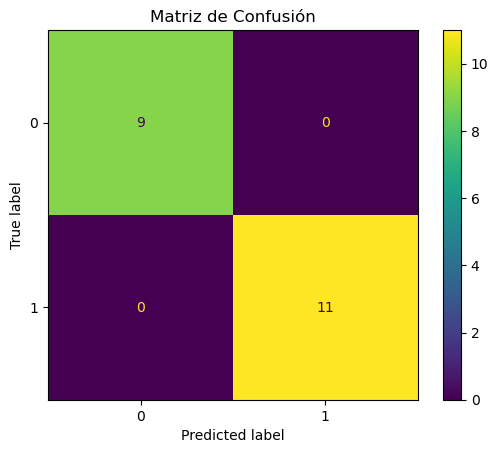

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Matriz de Confusión")
plt.show()

#### Análisis de errores

La matriz de confusión permite identificar cómo se distribuyen las predicciones correctas e incorrectas del modelo.

- Los verdaderos positivos representan clientes correctamente identificados como clientes que regresarán.
- Los verdaderos negativos representan clientes correctamente clasificados como clientes que no regresarán.

Por otro lado:
- Los falsos positivos corresponden a clientes que el modelo predijo que regresarían, pero no lo hicieron.
- Los falsos negativos representan clientes que sí regresarían, pero el modelo no logró identificar.

En un contexto empresarial, los falsos negativos pueden ser especialmente importantes, ya que representan clientes potencialmente recuperables que podrían perderse por falta de intervención.

Aunque el modelo presenta un buen desempeño general, aún existen errores de clasificación que podrían impactar estrategias de retención. Reducir los falsos negativos sería especialmente importante para minimizar la pérdida de clientes potenciales.

## 10. Conclusiones y Recomendaciones

### 10.1 Conclusiones

En este proyecto se desarrollaron y evaluaron distintos modelos de clasificación para predecir si un cliente regresará el siguiente mes.

A través del análisis exploratorio, el preprocesamiento de datos y la evaluación de modelos, fue posible identificar patrones relevantes relacionados con el comportamiento de los clientes.

Tras comparar los modelos de Regresión Logística, Árbol de Decisión y Bosque Aleatorio, el modelo de Bosque Aleatorio presentó el mejor desempeño general, especialmente en métricas como accuracy, F1-score y capacidad de generalización.

Además, la optimización de hiperparámetros mediante GridSearchCV permitió mejorar el desempeño del modelo respecto a su configuración inicial.

### 10.2 Recomendaciones de propuestas de aplicación en estrategias

Con base en los resultados obtenidos, se proponen las siguientes recomendaciones:

- Implementar estrategias de retención enfocadas en clientes con alta probabilidad de no regresar.
- Utilizar modelos predictivos como apoyo en campañas de marketing personalizado.
- Monitorear periódicamente variables como frecuencia de compra y tiempo desde la última compra.
- Actualizar y reentrenar el modelo con nuevos datos para mantener su desempeño a lo largo del tiempo.

Estas acciones podrían contribuir a mejorar la fidelización de clientes y optimizar la toma de decisiones empresariales.

### 10.3 Limitaciones del proyecto

Aunque el modelo mostró un desempeño adecuado, existen algunas limitaciones:

- El dataset utilizado es sintético y puede no representar completamente escenarios reales.
- El desempeño del modelo depende de la calidad y cantidad de datos disponibles.
- Algunas variables potencialmente relevantes podrían no estar incluidas en el dataset.

Por ello, futuros trabajos podrían incorporar datos más complejos y técnicas avanzadas de machine learning.

### 10.4 Trabajo Futuro

Como mejoras futuras se podrían considerar:

- Probar modelos más avanzados como XGBoost o redes neuronales.
- Aplicar técnicas de balanceo de clases si existiera desbalance en los datos.
- Incorporar nuevas variables relacionadas con comportamiento del cliente.
- Implementar validación más robusta y análisis de interpretabilidad del modelo.

Sección 12 — Anexos / organización final